In [1]:
"""
# 15. Estrategias para datasets pequeños e imágenes sintéticas

## Objetivos
- Entender los desafíos de entrenar con pocos datos
- Aplicar técnicas de "data augmentation" avanzada
- Generar imágenes sintéticas con "Keras ImageDataGenerator" y transformaciones manuales
- Comparar el impacto de distintas estrategias sobre el accuracy
- Simular un escenario real de dataset pequeño con CIFAR-10

## Motivación
En proyectos reales raramente tenemos 50.000 imágenes etiquetadas.
Lo más común es tener cientos o pocos miles de muestras.
Este notebook simula ese escenario y evalúa estrategias para sacar el máximo provecho de datos limitados.
## ¿Por qué los datasets pequeños son difíciles?

Con pocos datos, las redes neuronales tienden a:
- "Memorizar" el training set en lugar de generalizar
- "Sobreajustar" rápidamente — train accuracy alta, val baja
- Ser muy sensibles a la inicialización de pesos

### Estrategias principales

| Estrategia | Descripción | Cuándo usar |
|---|---|---|
| Data Augmentation | Transformaciones sobre imágenes existentes | Siempre |
| Transfer Learning | Partir de pesos preentrenados | Dataset < 10k |
| Feature Extraction | Congelar base, entrenar solo clasificador | Dataset muy pequeño |
| Imágenes sintéticas | Generar nuevas muestras artificiales | Dataset < 1k |
| Mixup / CutMix | Combinar imágenes y etiquetas | Dataset mediano |

En este notebook vamos a explorar todas estas estrategias sobre un subset reducido de CIFAR-10 (500 imágenes por clase).
"""

'\n# 15. Estrategias para datasets pequeños e imágenes sintéticas\n\n## Objetivos\n- Entender los desafíos de entrenar con pocos datos\n- Aplicar técnicas de "data augmentation" avanzada\n- Generar imágenes sintéticas con "Keras ImageDataGenerator" y transformaciones manuales\n- Comparar el impacto de distintas estrategias sobre el accuracy\n- Simular un escenario real de dataset pequeño con CIFAR-10\n\n## Motivación\nEn proyectos reales raramente tenemos 50.000 imágenes etiquetadas.\nLo más común es tener cientos o pocos miles de muestras.\nEste notebook simula ese escenario y evalúa estrategias para sacar el máximo provecho de datos limitados.\n## ¿Por qué los datasets pequeños son difíciles?\n\nCon pocos datos, las redes neuronales tienden a:\n- "Memorizar" el training set en lugar de generalizar\n- "Sobreajustar" rápidamente — train accuracy alta, val baja\n- Ser muy sensibles a la inicialización de pesos\n\n### Estrategias principales\n\n| Estrategia | Descripción | Cuándo usar |\

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")

TensorFlow version: 2.21.0
Keras version:      3.14.0


In [3]:
# Simulamos un escenario real: solo 500 imágenes por clase
# Total: 5000 imágenes de entrenamiento (10% del CIFAR-10 original)

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32")       / 255.0
y_train_full = y_train_full.flatten()
y_test       = y_test.flatten()

SAMPLES_PER_CLASS = 500

x_small, y_small = [], []
for cls in range(10):
    idx = np.where(y_train_full == cls)[0][:SAMPLES_PER_CLASS]
    x_small.append(x_train_full[idx])
    y_small.append(y_train_full[idx])

x_small = np.concatenate(x_small)
y_small = np.concatenate(y_small)

# Shuffle
shuffle_idx = np.random.permutation(len(x_small))
x_small = x_small[shuffle_idx]
y_small = y_small[shuffle_idx]

# Validación: 20% del dataset pequeño
split = int(len(x_small) * 0.8)
x_train_s, x_val_s = x_small[:split], x_small[split:]
y_train_s, y_val_s = y_small[:split], y_small[split:]

print(f"Train pequeño:  {x_train_s.shape}  ({len(x_train_s)} imágenes)")
print(f"Validación:     {x_val_s.shape}")
print(f"Test:           {x_test.shape}  (completo)")

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train pequeño:  (4000, 32, 32, 3)  (4000 imágenes)
Validación:     (1000, 32, 32, 3)
Test:           (10000, 32, 32, 3)  (completo)


In [4]:
"""
## Data Augmentation

La idea es expandir artificialmente el dataset aplicando transformaciones que preservan la etiqueta:
imagen original → flip horizontal → rotación → brillo → zoom → ...

### Transformaciones comunes
| Transformación | Descripción | Rango típico |
|---|---|---|
| Flip horizontal | Espejo izquierda-derecha | — |
| Rotación | Rotar la imagen | ±15° |
| Zoom | Acercar/alejar | ±10% |
| Brillo | Cambiar luminosidad | ±20% |
| Contraste | Cambiar contraste | ±10% |
| Traslación | Desplazar la imagen | ±10% |
| Cutout | Eliminar región aleatoria | 16×16 px |

### Regla clave
Las augmentations deben ser "realistas" — una rotación de 180°
no tiene sentido para un auto pero sí para una célula microscópica.
"""

'\n## Data Augmentation\n\nLa idea es expandir artificialmente el dataset aplicando transformaciones que preservan la etiqueta:\nimagen original → flip horizontal → rotación → brillo → zoom → ...\n\n### Transformaciones comunes\n| Transformación | Descripción | Rango típico |\n|---|---|---|\n| Flip horizontal | Espejo izquierda-derecha | — |\n| Rotación | Rotar la imagen | ±15° |\n| Zoom | Acercar/alejar | ±10% |\n| Brillo | Cambiar luminosidad | ±20% |\n| Contraste | Cambiar contraste | ±10% |\n| Traslación | Desplazar la imagen | ±10% |\n| Cutout | Eliminar región aleatoria | 16×16 px |\n\n### Regla clave\nLas augmentations deben ser "realistas" — una rotación de 180°\nno tiene sentido para un auto pero sí para una célula microscópica.\n'

In [5]:
# Augmentation básica
augment_basic = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment_basic")

# Augmentation agresiva
augment_strong = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.10, value_range=(0.0, 1.0)),
], name="augment_strong")

print("Capas de augmentation definidas ✓")

Capas de augmentation definidas ✓


In [6]:
def make_dataset(x, y, batch_size=64, augment_fn=None):
    """Pipeline estándar con etiquetas enteras."""
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(5000)

    ds = ds.map(
        lambda img, lbl: (tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), lbl),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment_fn is not None:
        ds = ds.map(
            lambda img, lbl: (
                tf.clip_by_value(
                    augment_fn(img[tf.newaxis], training=True)[0],
                    0.0,
                    1.0
                ),
                lbl
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

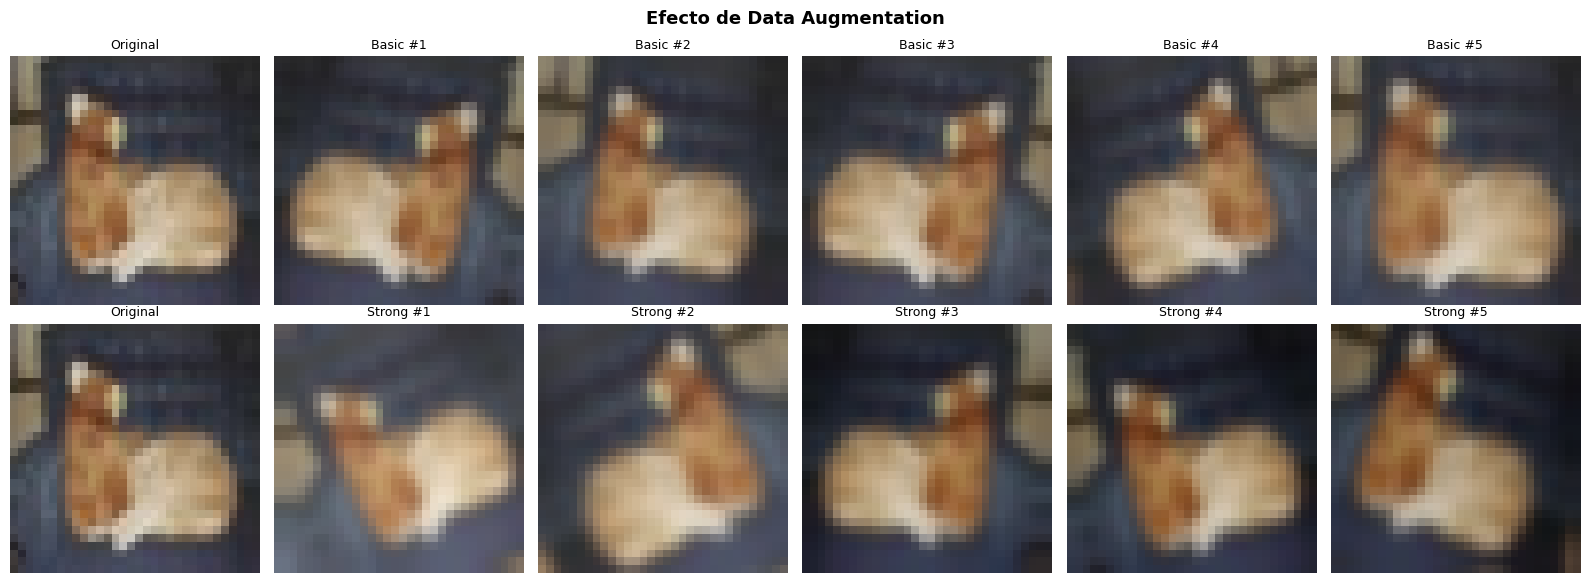

Figura guardada ✓


In [7]:
# Mostrar el efecto de cada augmentation sobre una imagen
sample_img = x_train_s[0]

fig, axes = plt.subplots(2, 6, figsize=(16, 6))

# Fila 1 — augmentation básica
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title("Original", fontsize=9)
axes[0, 0].axis("off")

for i in range(1, 6):
    aug_img = augment_basic(
        tf.expand_dims(sample_img, 0), training=True
    )[0].numpy()
    aug_img = np.clip(aug_img, 0, 1)
    axes[0, i].imshow(aug_img)
    axes[0, i].set_title(f"Basic #{i}", fontsize=9)
    axes[0, i].axis("off")

# Fila 2 — augmentation agresiva
axes[1, 0].imshow(sample_img)
axes[1, 0].set_title("Original", fontsize=9)
axes[1, 0].axis("off")

for i in range(1, 6):
    aug_img = augment_strong(
        tf.expand_dims(sample_img, 0), training=True
    )[0].numpy()
    aug_img = np.clip(aug_img, 0, 1)
    axes[1, i].imshow(aug_img)
    axes[1, i].set_title(f"Strong #{i}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Efecto de Data Augmentation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/15_augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

In [8]:
"""
## Mixup

Mixup es una técnica de augmentation que combina dos imágenes y sus etiquetas con un factor λ ∈ [0, 1]:
imagen_mixup = λ * imagen_A + (1 - λ) * imagen_B
etiqueta_mixup = λ * etiqueta_A + (1 - λ) * etiqueta_B

Esto obliga al modelo a aprender fronteras de decisión más suaves y mejora la generalización, especialmente con datasets pequeños.

λ se samplea de una distribución Beta(α, α) donde α típicamente vale 0.2 — valores cercanos a 0 o 1 dominan, preservando
la imagen original la mayor parte del tiempo.
"""

'\n## Mixup\n\nMixup es una técnica de augmentation que combina dos imágenes y sus etiquetas con un factor λ ∈ [0, 1]:\nimagen_mixup = λ * imagen_A + (1 - λ) * imagen_B\netiqueta_mixup = λ * etiqueta_A + (1 - λ) * etiqueta_B\n\nEsto obliga al modelo a aprender fronteras de decisión más suaves y mejora la generalización, especialmente con datasets pequeños.\n\nλ se samplea de una distribución Beta(α, α) donde α típicamente vale 0.2 — valores cercanos a 0 o 1 dominan, preservando\nla imagen original la mayor parte del tiempo.\n'

In [9]:
def mixup(x, y, alpha=0.2):
    batch_size = tf.shape(x)[0]

    lam = tf.random.gamma([], alpha, 1.0)
    lam = tf.maximum(lam, 1.0 - lam)

    idx = tf.random.shuffle(tf.range(batch_size))

    x_mix = lam * x + (1.0 - lam) * tf.gather(x, idx)
    y_mix = lam * y + (1.0 - lam) * tf.gather(y, idx)

    return x_mix, y_mix


def make_dataset_mixup(x, y, batch_size=64, augment_fn=None):
    """Pipeline con Mixup — etiquetas one-hot."""
    y_onehot = tf.one_hot(y, depth=10)

    ds = tf.data.Dataset.from_tensor_slices((x, y_onehot))
    ds = ds.shuffle(5000)

    ds = ds.map(
        lambda img, lbl: (tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), lbl),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if augment_fn is not None:
        ds = ds.map(
            lambda img, lbl: (
                tf.clip_by_value(
                    augment_fn(img[tf.newaxis], training=True)[0],
                    0.0,
                    1.0
                ),
                lbl
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(batch_size)

    ds = ds.map(
        lambda x, y: mixup(x, y, alpha=0.2),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.prefetch(tf.data.AUTOTUNE)

print("make_dataset_mixup actualizada ✓")

make_dataset_mixup actualizada ✓


In [10]:
IMG_SIZE   = 96
BATCH_SIZE = 64

def build_model(use_augment_layer=None):
    """
    EfficientNetB0 con fine-tuning parcial.
    Acepta opcionalmente una capa de augmentation integrada.
    """
    base = keras.applications.EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = True
    for layer in base.layers[:100]:
        layer.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x      = inputs

    if use_augment_layer is not None:
        x = use_augment_layer(x)

    # Preprocess + resize dentro del modelo
    x = tf.keras.layers.Lambda(
        lambda img: keras.applications.efficientnet.preprocess_input(
            tf.image.resize(img * 255.0, (IMG_SIZE, IMG_SIZE))
        )
    )(x)

    x       = base(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation="relu")(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

print("Función build_model lista ✓")

Función build_model lista ✓


In [11]:
def train_strategy(model, train_ds, val_ds, model_name,
                   use_mixup=False, epochs=30):

    loss_fn = (keras.losses.CategoricalCrossentropy() if use_mixup
               else keras.losses.SparseCategoricalCrossentropy())

    optimizer = keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        filepath=f"../models/15_{model_name}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
    early_stopping_cb = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=0
    )

    # Validación: si usamos Mixup convertimos etiquetas a one-hot
    # para que sean compatibles con CategoricalCrossentropy
    if use_mixup:
        val_ds_final = (
            tf.data.Dataset.from_tensor_slices((x_val_s, y_val_s))
            .map(lambda img, lbl: (
                tf.image.resize(img, (IMG_SIZE, IMG_SIZE)),
                tf.one_hot(lbl, depth=10)
            ), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
        )
    else:
        val_ds_final = (
            tf.data.Dataset.from_tensor_slices((x_val_s, y_val_s))
            .map(lambda img, lbl: (
                tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), lbl
            ), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
        )

    t0 = time.time()
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds_final,
        callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"\n{model_name} — {elapsed/60:.1f} min ✓")

    return history, elapsed

print("train_strategy actualizada ✓")

train_strategy actualizada ✓


In [14]:
#def make_dataset(x, y, batch_size=64, augment_fn=None):
"""Pipeline estándar con etiquetas enteras."""
"""
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(5000)
    ds = ds.map(
        lambda img, lbl: (tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), lbl),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if augment_fn is not None:
        ds = ds.map(
            lambda img, lbl: (augment_fn(img[tf.newaxis], training=True)[0], lbl),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
"""

def make_dataset_mixup(x, y, batch_size=64, augment_fn=None):
    """Pipeline con Mixup — etiquetas one-hot."""
    y_onehot = tf.one_hot(y, depth=10)
    ds = tf.data.Dataset.from_tensor_slices((x, y_onehot))
    ds = ds.shuffle(5000)
    ds = ds.map(
        lambda img, lbl: (tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), lbl),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if augment_fn is not None:
        ds = ds.map(
            lambda img, lbl: (augment_fn(img[tf.newaxis], training=True)[0], lbl),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    ds = ds.batch(batch_size)
    ds = ds.map(
        lambda x, y: mixup(x, y, alpha=0.2),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return ds.prefetch(tf.data.AUTOTUNE)

print("Pipelines actualizados ✓")

Pipelines actualizados ✓


In [15]:
print("=" * 45)
print("Estrategia 1 — Sin augmentation (baseline)")
print("=" * 45)

train_ds_base = make_dataset(x_train_s, y_train_s)

model_base = build_model(use_augment_layer=None)
history_base, time_base = train_strategy(
    model_base, train_ds_base, None,
    model_name="baseline"
)

Estrategia 1 — Sin augmentation (baseline)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.3117 - loss: 2.0030 - val_accuracy: 0.6190 - val_loss: 1.4030 - learning_rate: 1.0000e-04
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6800 - loss: 1.0971 - val_accuracy: 0.7640 - val_loss: 0.8298 - learning_rate: 1.0000e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8117 - loss: 0.6450 - val_accuracy: 0.8060 - val_loss: 0.6063 - learning_rate: 1.0000e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8712 - loss: 0.4337 - val_accuracy: 0.8270 - val_loss: 0.5207 - learning_rate: 1.0000e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9100 - loss: 0.3074 - val_accuracy: 0.8450 - val_loss: 0.4784 - learning_rate: 1.0000e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9327 - loss: 0.2268 - val_accuracy: 0.8480 - val_loss: 0.4668 - learning_rate: 1.0000e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━

In [16]:
print("=" * 45)
print("Estrategia 2 — Augmentation básica")
print("=" * 45)

train_ds_aug_basic = make_dataset(x_train_s, y_train_s, augment_fn=augment_basic)

model_aug_basic = build_model(use_augment_layer=None)
history_aug_basic, time_aug_basic = train_strategy(
    model_aug_basic, train_ds_aug_basic, None,
    model_name="aug_basic"
)

Estrategia 2 — Augmentation básica
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.2750 - loss: 2.0865 - val_accuracy: 0.5920 - val_loss: 1.4907 - learning_rate: 1.0000e-04
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5755 - loss: 1.3179 - val_accuracy: 0.7370 - val_loss: 0.8783 - learning_rate: 1.0000e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6990 - loss: 0.9252 - val_accuracy: 0.8090 - val_loss: 0.6343 - learning_rate: 1.0000e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.7747 - loss: 0.6967 - val_accuracy: 0.8330 - val_loss: 0.5234 - learning_rate: 1.0000e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8092 - loss: 0.5690 - val_accuracy: 0.8510 - val_loss: 0.4743 - learning_rate: 1.0000e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8460 - loss: 0.4538 - val_accuracy: 0.8600 - val_loss: 0.4490 - learning_rate: 1.0000e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 74

In [17]:
print("=" * 45)
print("Estrategia 3 — Augmentation agresiva")
print("=" * 45)

train_ds_aug_strong = make_dataset(x_train_s, y_train_s, augment_fn=augment_strong)

model_aug_strong = build_model(use_augment_layer=None)
history_aug_strong, time_aug_strong = train_strategy(
    model_aug_strong, train_ds_aug_strong, None,
    model_name="aug_strong"
)

Estrategia 3 — Augmentation agresiva
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.2558 - loss: 2.0913 - val_accuracy: 0.5540 - val_loss: 1.5451 - learning_rate: 1.0000e-04
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5638 - loss: 1.3628 - val_accuracy: 0.7280 - val_loss: 0.9314 - learning_rate: 1.0000e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7190 - loss: 0.8821 - val_accuracy: 0.7990 - val_loss: 0.6604 - learning_rate: 1.0000e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7800 - loss: 0.6745 - val_accuracy: 0.8250 - val_loss: 0.5431 - learning_rate: 1.0000e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8288 - loss: 0.5444 - val_accuracy: 0.8410 - val_loss: 0.4839 - learning_rate: 1.0000e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8370 - loss: 0.4633 - val_accuracy: 0.8560 - val_loss: 0.4446 - learning_rate: 1.0000e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 

In [18]:
print("=" * 45)
print("Estrategia 4 — Augmentation agresiva + Mixup")
print("=" * 45)

train_ds_mixup = make_dataset_mixup(x_train_s, y_train_s, augment_fn=augment_strong)

model_mixup = build_model(use_augment_layer=None)
history_mixup, time_mixup = train_strategy(
    model_mixup, train_ds_mixup, None,
    model_name="mixup",
    use_mixup=True
)

Estrategia 4 — Augmentation agresiva + Mixup
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.2163 - loss: 2.2222 - val_accuracy: 0.4530 - val_loss: 1.7742 - learning_rate: 1.0000e-04
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.4568 - loss: 1.6874 - val_accuracy: 0.6800 - val_loss: 1.1990 - learning_rate: 1.0000e-04
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5970 - loss: 1.3386 - val_accuracy: 0.7560 - val_loss: 0.8907 - learning_rate: 1.0000e-04
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.6675 - loss: 1.1215 - val_accuracy: 0.7880 - val_loss: 0.7079 - learning_rate: 1.0000e-04
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7100 - loss: 1.0369 - val_accuracy: 0.7980 - val_loss: 0.6664 - learning_rate: 1.0000e-04
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7390 - loss: 0.9801 - val_accuracy: 0.8110 - val_loss: 0.6336 - learning_rate: 1.0000e-04
Epoch 7/30
63/63 ━━━━━━━━━━━━━

In [19]:
"""
### Interpretación

La primera versión de la estrategia de augmentation agresiva hizo que el modelo colapsara a un rendimiento casi aleatorio, 
con una accuracy de validación cercana al 10%, que es lo esperado en CIFAR-10 cuando el modelo predice prácticamente al azar.

Después de reducir la intensidad de las transformaciones y limitar explícitamente los valores de las imágenes aumentadas al 
rango válido "[0, 1]", el modelo volvió a entrenar correctamente. La combinación de augmentation fuerte pero controlada con Mixup 
alcanzó una accuracy de validación cercana al 86%, mostrando que Mixup puede mejorar la robustez siempre que las imágenes aumentadas 
conserven información visual relevante para la clase.

Este resultado muestra una lección práctica importante: la augmentation no siempre ayuda. Si las transformaciones son demasiado fuertes, 
pueden destruir el contenido semántico de la imagen y evitar que el modelo aprenda.
"""

'\n### Interpretación\n\nLa primera versión de la estrategia de augmentation agresiva hizo que el modelo colapsara a un rendimiento casi aleatorio, \ncon una accuracy de validación cercana al 10%, que es lo esperado en CIFAR-10 cuando el modelo predice prácticamente al azar.\n\nDespués de reducir la intensidad de las transformaciones y limitar explícitamente los valores de las imágenes aumentadas al \nrango válido "[0, 1]", el modelo volvió a entrenar correctamente. La combinación de augmentation fuerte pero controlada con Mixup \nalcanzó una accuracy de validación cercana al 86%, mostrando que Mixup puede mejorar la robustez siempre que las imágenes aumentadas \nconserven información visual relevante para la clase.\n\nEste resultado muestra una lección práctica importante: la augmentation no siempre ayuda. Si las transformaciones son demasiado fuertes, \npueden destruir el contenido semántico de la imagen y evitar que el modelo aprenda.\n'

In [22]:
def evaluate_model_from_memory(model, test_ds):
    loss, acc = model.evaluate(test_ds, verbose=0)
    return acc

In [23]:
test_ds_eval = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .map(lambda img, lbl: (
        tf.image.resize(img, (IMG_SIZE, IMG_SIZE)),
        lbl
    ), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [27]:
test_ds_eval_onehot = (
    tf.data.Dataset.from_tensor_slices((x_test, tf.one_hot(y_test, depth=10)))
    .map(lambda img, lbl: (
        tf.image.resize(img, (IMG_SIZE, IMG_SIZE)),
        lbl
    ), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [28]:
acc_base       = evaluate_model_from_memory(model_base,       test_ds_eval)
acc_aug_basic  = evaluate_model_from_memory(model_aug_basic,  test_ds_eval)
acc_aug_strong = evaluate_model_from_memory(model_aug_strong, test_ds_eval)

acc_mixup      = evaluate_model_from_memory(model_mixup,      test_ds_eval_onehot)

In [29]:
print("=" * 56)
print(f"  {'Estrategia':<36} {'Test Acc':>10}")
print("=" * 56)
print(f"  {'Sin augmentation (baseline)':<36} {acc_base:>9.2%}")
print(f"  {'Augmentation básica':<36} {acc_aug_basic:>9.2%}")
print(f"  {'Augmentation agresiva':<36} {acc_aug_strong:>9.2%}")
print(f"  {'Augmentation agresiva + Mixup':<36} {acc_mixup:>9.2%}")
print("=" * 56)

  Estrategia                             Test Acc
  Sin augmentation (baseline)             86.89%
  Augmentation básica                     87.10%
  Augmentation agresiva                   87.34%
  Augmentation agresiva + Mixup           85.76%


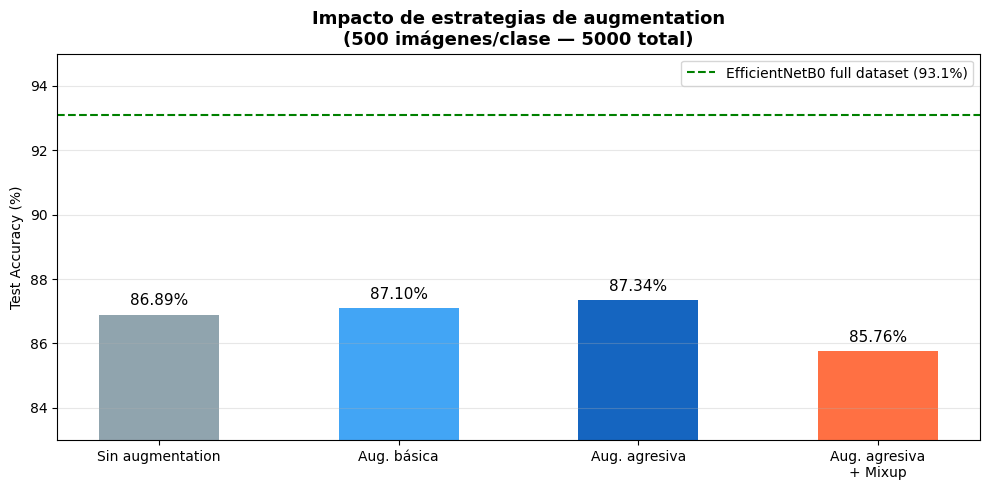

Figura guardada ✓


In [30]:
estrategias = [
    "Sin augmentation",
    "Aug. básica",
    "Aug. agresiva",
    "Aug. agresiva\n+ Mixup"
]
accuracies = [acc_base, acc_aug_basic, acc_aug_strong, acc_mixup]
colores    = ["#90A4AE", "#42A5F5", "#1565C0", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(estrategias, [a * 100 for a in accuracies],
              color=colores, width=0.5)

# Referencia full dataset
ax.axhline(y=93.1, color="green", linestyle="--",
           linewidth=1.5, label="EfficientNetB0 full dataset (93.1%)")

# Etiquetas sobre barras
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{acc:.2%}", ha="center", va="bottom", fontsize=11)

ax.set_title("Impacto de estrategias de augmentation\n(500 imágenes/clase — 5000 total)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Test Accuracy (%)")
ax.set_ylim(83, 95)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/15_augmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

In [36]:
"""
## Conclusiones

### Resultados — 500 imágenes/clase (10% del dataset)
| Estrategia                  | Test Accuracy | Δ vs baseline |
|-----------------------------|---------------|---------------|
| Sin augmentation            | 86.89%        | —             |
| Augmentation básica         | 87.10%        | +0.21%        |
| Augmentation agresiva       | 87.34%        | +0.45%        |
| Augmentation agresiva+Mixup | 85.76%        | -1.13%        |
| EfficientNetB0 full dataset | 93.1%         | referencia    |

### Observaciones

"Transfer learning es el héroe silencioso"
El baseline sin augmentation alcanza 86.89% con solo 5000 imágenes.
Esto demuestra el poder de los pesos preentrenados en ImageNet — el modelo ya sabe reconocer features relevantes antes de ver CIFAR-10.

"Augmentation ayuda, pero marginalmente"
Con transfer learning fuerte, la augmentation aporta poco — el modelo ya generaliza bien gracias a los pesos preentrenados.
Su impacto sería mucho mayor entrenando desde cero.

"Mixup no funcionó aquí"
Mixup está diseñado para datasets grandes donde el modelo puede sobreajustar. Con 5000 imágenes y transfer learning,
el modelo no sobreajusta tanto y Mixup introduce ruido innecesario en las etiquetas que perjudica el entrenamiento.

"El gap con el dataset completo es de ~6%" Para cerrar ese gap necesitaríamos más datos reales — las técnicas de augmentation no pueden sustituir
la diversidad de 50.000 imágenes reales.

### Próximo paso — README del proyecto
Con los 15 notebooks completados, el siguiente paso es documentar el proyecto completo en el README.
"""

'\n## Conclusiones\n\n### Resultados — 500 imágenes/clase (10% del dataset)\n| Estrategia                  | Test Accuracy | Δ vs baseline |\n|-----------------------------|---------------|---------------|\n| Sin augmentation            | 86.89%        | —             |\n| Augmentation básica         | 87.10%        | +0.21%        |\n| Augmentation agresiva       | 87.34%        | +0.45%        |\n| Augmentation agresiva+Mixup | 85.76%        | -1.13%        |\n| EfficientNetB0 full dataset | 93.1%         | referencia    |\n\n### Observaciones\n\n"Transfer learning es el héroe silencioso"\nEl baseline sin augmentation alcanza 86.89% con solo 5000 imágenes.\nEsto demuestra el poder de los pesos preentrenados en ImageNet — el modelo ya sabe reconocer features relevantes antes de ver CIFAR-10.\n\n"Augmentation ayuda, pero marginalmente"\nCon transfer learning fuerte, la augmentation aporta poco — el modelo ya generaliza bien gracias a los pesos preentrenados.\nSu impacto sería mucho may